# Exploring a website's structure and publishing trends using XML sitemaps

## Install packages

In [ ]:
!pip install advertools adviz pandas plotly

## Import packages

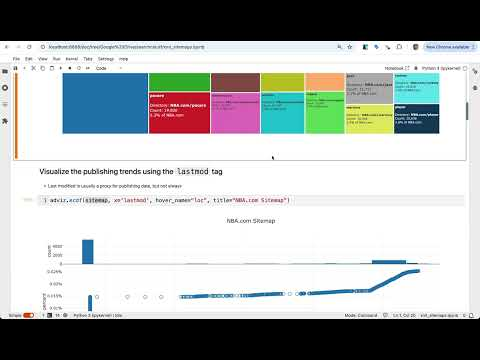

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo(id="6cJ8ibrzjno", width=560, height=315)

In [ ]:
import advertools as adv

import adviz

from dash_bootstrap_templates import load_figure_template

load_figure_template("all")

## Fetch and parse the XML sitemap, convert to a DataFrame

In [ ]:
sitemap = adv.sitemap_to_df("https://www.nba.com/robots.txt")
sitemap.head()

,loc,sitemap,etag,sitemap_last_modified,sitemap_size_mb,download_date,lastmod,changefreq,priority,errors,news,news_publication,publication_name,publication_language,news_publication_date,news_title,image,image_loc,video,video_thumbnail_loc,video_title,video_content_loc,video_player_loc
0,https://nba.com/podcasts,https://nba.com/sitemap_podcast_series.xml,"""800226556b0dfe8b76d0c12d900b337f""",2025-07-15 05:00:44,0.000923,2025-07-15 14:00:56.039420+00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://nba.com/nba-dna-with-hannah-storm,https://nba.com/sitemap_podcast_series.xml,"""800226556b0dfe8b76d0c12d900b337f""",2025-07-15 05:00:44,0.000923,2025-07-15 14:00:56.039420+00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://nba.com/the-vc-show-with-vince-carter,https://nba.com/sitemap_podcast_series.xml,"""800226556b0dfe8b76d0c12d900b337f""",2025-07-15 05:00:44,0.000923,2025-07-15 14:00:56.039420+00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://nba.com/four-years-of-heat,https://nba.com/sitemap_podcast_series.xml,"""800226556b0dfe8b76d0c12d900b337f""",2025-07-15 05:00:44,0.000923,2025-07-15 14:00:56.039420+00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://nba.com/hoops-paradise-the-philippines-love-of-the-game,https://nba.com/sitemap_podcast_series.xml,"""800226556b0dfe8b76d0c12d900b337f""",2025-07-15 05:00:44,0.000923,2025-07-15 14:00:56.039420+00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
sitemap.shape

(377310, 23)

## Visualize the URL structure
- Display a treemap of showing the hierarchical counts of URL segments (first two levels)

In [14]:
adviz.url_structure(
    url_list=sitemap["loc"].dropna(),
    domain="NBA.com",
    title="URL Structure<br><b>NBA.com</b>",
    items_per_level=20,
    height=750,
    template="cosmo",
)

## Visualize the publishing trends using the `lastmod` tag

- Last modified is usually a proxy for publishing date, but not always

In [15]:
adviz.ecdf(
    sitemap.dropna(subset=["lastmod"]),
    x="lastmod",
    hover_name="loc",
    title="NBA.com Sitemap",
    subtitle="Only 9.6k URLs (~2.5%) have the lastmod tag",
    height=750,
    template="cosmo",
)

In [ ]:
adviz.value_counts(
    sitemap["lastmod"].notna(), height=270, title="URL has a <b><lastmod></b> tag"
)

---

## BONUS

## Filter URLs having a `lastmod` tag

In [13]:
lastmod_urls = sitemap[sitemap["lastmod"].notna()]["loc"]
lastmod_url_df = adv.url_to_df(lastmod_urls)
lastmod_url_df.head()

,url,scheme,netloc,path,query,fragment,dir_1,dir_2,dir_3,last_dir,dir_4,query_SeasonType
0,https://nba.com/stats,https,nba.com,/stats,None,None,stats,None,None,stats,None,None
1,https://nba.com/stats/players,https,nba.com,/stats/players,None,None,stats,players,None,players,None,None
2,https://nba.com/stats/teams,https,nba.com,/stats/teams,None,None,stats,teams,None,teams,None,None
3,https://nba.com/stats/playoffs,https,nba.com,/stats/playoffs,None,None,stats,playoffs,None,playoffs,None,None
4,https://nba.com/stats/spotlightarchive,https,nba.com,/stats/spotlightarchive,None,None,stats,spotlightarchive,None,spotlightarchive,None,None


## URLs with a `lastmod` tag values under `dir_1`

In [ ]:
adviz.value_counts(lastmod_url_df["dir_1"], height=350)

## URLs with a `lastmod` tag values under `dir_2`

In [15]:
adviz.value_counts(lastmod_url_df["dir_2"], height=450)

## Find errors in sitemaps

In [16]:
sitemap[sitemap["errors"].notna()][["sitemap", "errors"]]

,sitemap,errors
21,"https://nba.com/sitemap_games_1.xml,sitemap_games_2.xml",HTTP Error 403: Forbidden
281,"https://nba.com/sitemap_videos_2025_1.xml,sitemap_videos_2025_2.xml,sitemap_videos_2025_3.xml,sitemap_videos_2025_4....",HTTP Error 403: Forbidden
296,"https://nba.com/sitemaps/sitemap_videos_1.xml,sitemaps/sitemap_videos_10.xml,sitemaps/sitemap_videos_11.xml,sitemaps...",HTTP Error 400: Bad Request
20355,https://nba.com/,"not well-formed (invalid token): line 2, column 20"
23617,"https://nba.com/sitemap_team_cavaliers_videos_1.xml,sitemap_team_cavaliers_videos_2.xml",HTTP Error 403: Forbidden
23715,"https://nba.com/sitemap_team_cavaliers_news_1.xml,sitemap_team_cavaliers_news_2.xml",HTTP Error 403: Forbidden
36543,"https://nba.com/sitemap_team_pelicans_news_1.xml,sitemap_team_pelicans_news_2.xml",HTTP Error 403: Forbidden
36694,"https://nba.com/sitemap_team_pelicans_videos_1.xml,sitemap_team_pelicans_videos_2.xml",HTTP Error 403: Forbidden
56537,"https://nba.com/sitemap_team_warriors_videos_1.xml,sitemap_team_warriors_videos_2.xml,sitemap_team_warriors_videos_3...",HTTP Error 403: Forbidden
98551,"https://nba.com/sitemap_team_bucks_videos_1.xml,sitemap_team_bucks_videos_2.xml",HTTP Error 403: Forbidden


In [17]:
urldf = adv.url_to_df(sitemap["loc"].dropna())
urldf.head()

,url,scheme,netloc,path,query,fragment,dir_1,dir_2,dir_3,dir_4,last_dir,dir_5,dir_6,dir_7,dir_8,dir_9,dir_10,query_SeasonType,dir_11,dir_12,dir_13,dir_14
0,https://nba.com/stats,https,nba.com,/stats,None,None,stats,None,None,None,stats,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
1,https://nba.com/stats/players,https,nba.com,/stats/players,None,None,stats,players,None,None,players,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
2,https://nba.com/stats/teams,https,nba.com,/stats/teams,None,None,stats,teams,None,None,teams,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
3,https://nba.com/stats/playoffs,https,nba.com,/stats/playoffs,None,None,stats,playoffs,None,None,playoffs,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
4,https://nba.com/stats/spotlightarchive,https,nba.com,/stats/spotlightarchive,None,None,stats,spotlightarchive,None,None,spotlightarchive,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN


In [18]:
adviz.value_counts(urldf["dir_1"])

In [19]:
adviz.value_counts(urldf["dir_1"], show_top=35, height=950)

## Get the top teams

In [20]:
top_teams = urldf["dir_1"].value_counts().head(35).index

## What is in `dir_2` for URLs that are about teams?

- Take the DataFrmae `urldf`
- Filter for rows where `dir_1` is in `top_teams`
- Count the values of `dir_2`

In [22]:
adviz.value_counts(urldf[urldf["dir_1"].isin(top_teams)]["dir_2"])

## What about players?

In [23]:
urldf[urldf["dir_1"].eq("player")]

,url,scheme,netloc,path,query,fragment,dir_1,dir_2,dir_3,dir_4,last_dir,dir_5,dir_6,dir_7,dir_8,dir_9,dir_10,query_SeasonType,dir_11,dir_12,dir_13,dir_14
297,https://nba.com/player/1630220/paul-eboua,https,nba.com,/player/1630220/paul-eboua,None,None,player,1630220,paul-eboua,None,paul-eboua,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
298,https://nba.com/player/1630220/paul-eboua/bio,https,nba.com,/player/1630220/paul-eboua/bio,None,None,player,1630220,paul-eboua,bio,bio,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
299,https://nba.com/player/1629700/kaleb-wesson,https,nba.com,/player/1629700/kaleb-wesson,None,None,player,1629700,kaleb-wesson,None,kaleb-wesson,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
300,https://nba.com/player/1629700/kaleb-wesson/bio,https,nba.com,/player/1629700/kaleb-wesson/bio,None,None,player,1629700,kaleb-wesson,bio,bio,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
301,https://nba.com/player/1630247/derrick-alston-jr,https,nba.com,/player/1630247/derrick-alston-jr,None,None,player,1630247,derrick-alston-jr,None,derrick-alston-jr,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10942,https://nba.com/player/1630172/patrick-williams/bio,https,nba.com,/player/1630172/patrick-williams/bio,None,None,player,1630172,patrick-williams,bio,bio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10943,https://nba.com/player/1630533/ziaire-williams,https,nba.com,/player/1630533/ziaire-williams,None,None,player,1630533,ziaire-williams,None,ziaire-williams,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10944,https://nba.com/player/1630533/ziaire-williams/bio,https,nba.com,/player/1630533/ziaire-williams/bio,None,None,player,1630533,ziaire-williams,bio,bio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10945,https://nba.com/player/1642262/cody-williams,https,nba.com,/player/1642262/cody-williams,None,None,player,1642262,cody-williams,None,cody-williams,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## How many pages do they have per player under `/player/`?

In [24]:
urldf[urldf["dir_1"].eq("player")]["dir_2"].value_counts()

dir_2
1630220    2
1629700    2
1630247    2
1630808    2
1630837    2
          ..
1629684    2
1631119    2
1630172    2
1630533    2
1642262    2
Name: count, Length: 5325, dtype: int64

In [25]:
urldf[urldf["dir_1"].eq("player")]["dir_3"].value_counts()

dir_3
george-johnson      6
charles-smith       6
chris-smith         6
cedric-henderson    4
steven-smith        4
                   ..
ivica-zubac         2
grant-williams      2
patrick-williams    2
ziaire-williams     2
johni-broome        2
Name: count, Length: 5281, dtype: int64